In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('data_praktikum_analisis_data.csv')
df.head()

,Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
0,1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0
1,1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0
2,1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0
3,1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0
4,1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          150 non-null    int64  
 1   CustomerID        150 non-null    int64  
 2   Order_Date        150 non-null    object 
 3   Product_Category  150 non-null    object 
 4   Quantity          150 non-null    int64  
 5   Price_Per_Unit    150 non-null    float64
 6   Ad_Budget         150 non-null    float64
 7   Total_Sales       143 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 9.5+ KB


In [6]:
df.isnull().sum()

,0
Order_ID,0
CustomerID,0
Order_Date,0
Product_Category,0
Quantity,0
Price_Per_Unit,0
Ad_Budget,0
Total_Sales,7


In [7]:
df = df[df['Price_Per_Unit'] > 0]
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [8]:
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('Month')['Total_Sales'].sum()

print(monthly_sales)

Month
2023-01    19910000.0
2023-02    39524000.0
2023-03    24003000.0
2023-04    45084000.0
2023-05    50372000.0
2023-06    44580000.0
2023-07    21909000.0
2023-08    83500000.0
2023-09    42062000.0
2023-10    23454000.0
2023-11    34654000.0
2023-12    29025000.0
Name: Total_Sales, dtype: float64


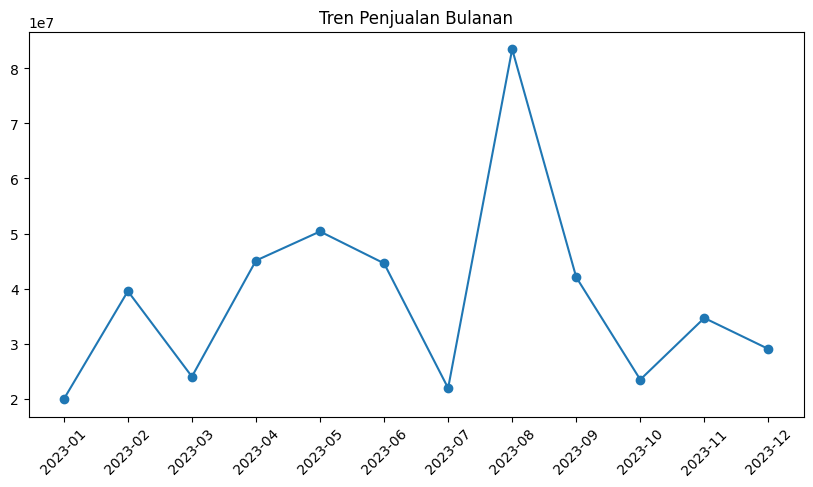

In [9]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Tren Penjualan Bulanan')
plt.xticks(rotation=45)
plt.show()

In [10]:
correlation = df[['Total_Sales','Ad_Budget','Quantity','Price_Per_Unit']].corr()

print(correlation)

                Total_Sales  Ad_Budget  Quantity  Price_Per_Unit
Total_Sales        1.000000   0.054778  0.644931        0.686168
Ad_Budget          0.054778   1.000000  0.106744       -0.053446
Quantity           0.644931   0.106744  1.000000        0.016773
Price_Per_Unit     0.686168  -0.053446  0.016773        1.000000


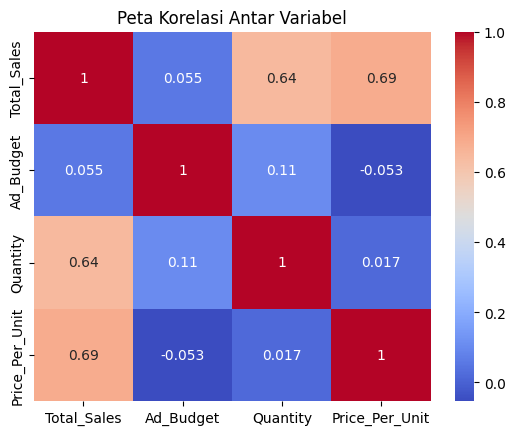

In [11]:
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antar Variabel')
plt.show()